##### Dataset GOOGL & INTC

In [ ]:
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import random

seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
# 1. Silence unnecessary warnings from TensorFlow
tf.get_logger().setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

DatasetPathGOOGL = "/kaggle/input/datasets/hylmirazzan/dataset-dl-uas-no1/GOOGL.csv"
DatasetPathINTC = "/kaggle/input/datasets/hylmirazzan/dataset-dl-uas-no1/INTC.csv"

GOOGL Alphabet Inc.

In [49]:
df_GOOGL = pd.read_csv(DatasetPathGOOGL, 
                 parse_dates=["Date"], 
                 index_col=["Date"])
df_GOOGL.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659000
2004-08-20,50.555557,54.594593,50.300301,54.209209,54.209209,22834300
2004-08-23,55.430431,56.796795,54.579578,54.754753,54.754753,18256100
2004-08-24,55.675674,55.855854,51.836838,52.487488,52.487488,15247300
2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188600


In [50]:
df_GOOGL = pd.DataFrame(df_GOOGL["Close"]).rename(columns={"Close": "Price"})
df_GOOGL

,Price
Date,
2004-08-19,50.220219
2004-08-20,54.209209
2004-08-23,54.754753
2004-08-24,52.487488
2004-08-25,53.053055
...,...
2020-03-26,1162.920044
2020-03-27,1110.260010
2020-03-30,1146.310059


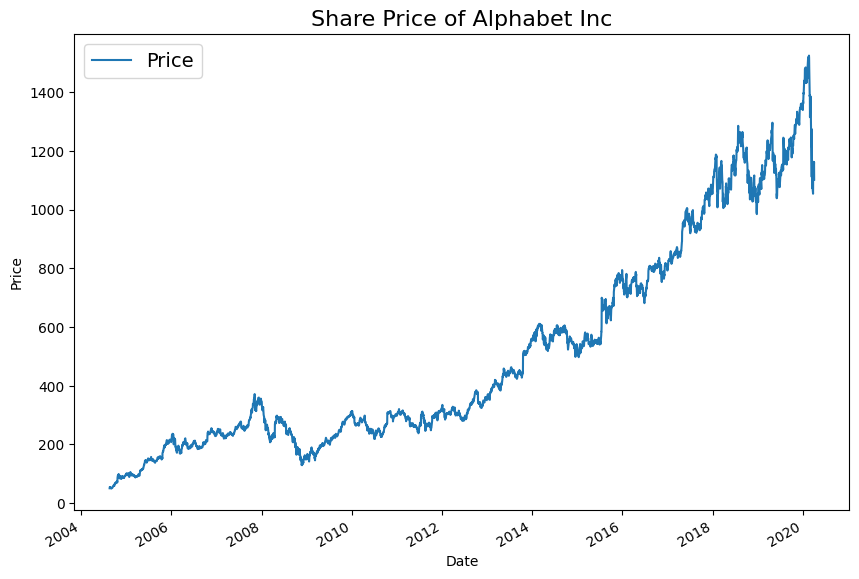

In [51]:
import matplotlib.pyplot as plt
df_GOOGL.plot(figsize=(10, 7))
plt.ylabel("Price")
plt.title("Share Price of Alphabet Inc", fontsize=16)
plt.legend(fontsize=14);

In [52]:
df_GOOGL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3932 entries, 2004-08-19 to 2020-04-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3932 non-null   float64
dtypes: float64(1)
memory usage: 61.4 KB


In [53]:
tanggal_terakhir = df_GOOGL.index.max()

batas_satu_tahun = tanggal_terakhir - pd.DateOffset(years=1)

print(f"Tanggal paling akhir di data: {tanggal_terakhir.date()}")
print(f"Batas potong 1 tahun terakhir: {batas_satu_tahun.date()}\n")

data_train_full = df_GOOGL[df_GOOGL.index < batas_satu_tahun]['Price'].values

data_test = df_GOOGL[df_GOOGL.index >= batas_satu_tahun]['Price'].values

print(f"Total data train awal: {len(data_train_full)} hari")
print(f"Total data test: {len(data_test)} hari")

Tanggal paling akhir di data: 2020-04-01
Batas potong 1 tahun terakhir: 2019-04-01

Total data train awal: 3678 hari
Total data test: 254 hari


In [54]:
def create_windows(data, window_size=5, horizon=1):
    x, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        x.append(data[i : i + window_size])
        y.append(data[i + window_size : i + window_size + horizon])
    return np.array(x), np.array(y)

window_size = 5
horizon = 1

x_train_windowed, y_train_windowed = create_windows(data_train_full, window_size, horizon)
x_test, y_test = create_windows(data_test, window_size, horizon)

In [55]:
split_size = int(0.9 * len(x_train_windowed))

x_train = x_train_windowed[:split_size]
y_train = y_train_windowed[:split_size]

x_val = x_train_windowed[split_size:]
y_val = y_train_windowed[split_size:]

print(f"x_train shape : {x_train.shape}, y_train shape : {y_train.shape}")
print(f"x_val shape   : {x_val.shape}, y_val shape   : {y_val.shape}")
print(f"x_test shape  : {x_test.shape}, y_test shape  : {y_test.shape}")

x_train shape : (3305, 5), y_train shape : (3305, 1)
x_val shape   : (368, 5), y_val shape   : (368, 1)
x_test shape  : (249, 5), y_test shape  : (249, 1)


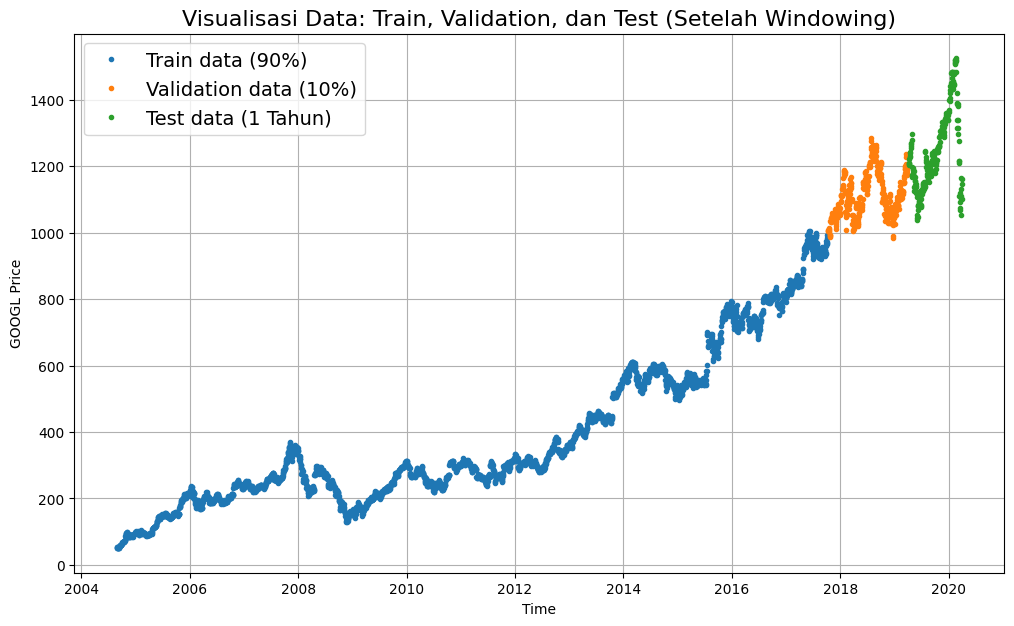

In [56]:
offset = window_size + horizon - 1
tabel_train = df_GOOGL[df_GOOGL.index < batas_satu_tahun]
tabel_test = df_GOOGL[df_GOOGL.index >= batas_satu_tahun]

timesteps_train_full = tabel_train.index
timesteps_test_full = tabel_test.index

timesteps_y_train_full = timesteps_train_full[offset:]
timesteps_y_test = timesteps_test_full[offset:]

timesteps_train = timesteps_y_train_full[:split_size]
timesteps_val = timesteps_y_train_full[split_size:]
timesteps_test = tabel_test.index


plt.figure(figsize=(12, 7))

plt.plot(timesteps_train, y_train.flatten(), ".", label="Train data (90%)")

plt.plot(timesteps_val, y_val.flatten(), ".", label="Validation data (10%)")

plt.plot(timesteps_y_test, y_test.flatten(), ".", label="Test data (1 Tahun)")

plt.xlabel("Time")
plt.ylabel("GOOGL Price")
plt.title("Visualisasi Data: Train, Validation, dan Test (Setelah Windowing)", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

Model Baseline GOOGL

In [57]:
x_train_3d = np.expand_dims(x_train, axis=-1)
x_val_3d = np.expand_dims(x_val, axis=-1)
x_test_3d = np.expand_dims(x_test, axis=-1)

print(f"x_train_3d shape : {x_train_3d.shape}")
print(f"x_val_3d shape   : {x_val_3d.shape}")
print(f"x_test_3d shape  : {x_test_3d.shape}\n")


model_baseline = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units=50, activation='relu', input_shape=(window_size, 1)),
    
    tf.keras.layers.Dense(units=1)
])


model_baseline.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_baseline.summary()

x_train_3d shape : (3305, 5, 1)
x_val_3d shape   : (368, 5, 1)
x_test_3d shape  : (249, 5, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
history_baseline = model_baseline.fit(
    x_train_3d, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_val_3d, y_val),
    verbose=1
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 22043.5215 - mae: 87.6910 - val_loss: 502.2655 - val_mae: 16.7751
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 74.5385 - mae: 5.7966 - val_loss: 451.0088 - val_mae: 16.5355
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 73.9738 - mae: 5.8392 - val_loss: 589.6879 - val_mae: 18.4843
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 65.6758 - mae: 5.5298 - val_loss: 446.5580 - val_mae: 16.7784
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 58.9695 - mae: 5.1766 - val_loss: 367.7769 - val_mae: 13.7389
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 57.0349 - mae: 5.0718 - val_loss: 411.2873 - val_mae: 14.6689
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 54.7626 - mae: 4.9505 - val_loss: 366.2090 - val_mae: 13.8687
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 54.6399 - mae: 4.9693 - val_loss: 358.2375 - val_mae: 13.5377
Epoch 9/20
104/104 

In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error 
import numpy as np

y_pred_baseline = model_baseline.predict(x_test_3d)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)

mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline)

print("\nEVALUASI MODEL BASELINE")
print(f"Nilai RMSE : {rmse_baseline:.4f}")
print(f"Nilai MAE  : {mae_baseline:.4f}")
print(f"Nilai MAPE : {mape_baseline:.4f} (atau setara dengan {mape_baseline * 100:.2f}%)")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step

EVALUASI MODEL BASELINE
Nilai RMSE : 30.4621
Nilai MAE  : 18.6373
Nilai MAPE : 0.0153 (atau setara dengan 1.53%)


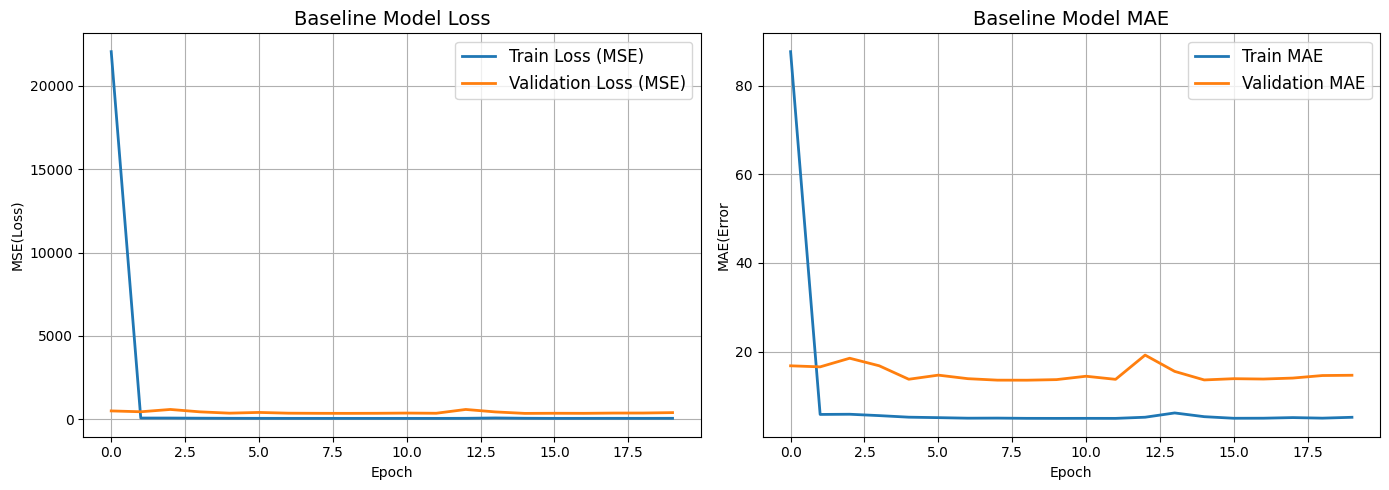

In [60]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history_baseline.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.title('Baseline Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE(Loss)')
plt.legend(fontsize=12)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history_baseline.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Baseline Model MAE', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MAE(Error')
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

Model Modifikasi GOOGL

In [61]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

model_mod = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(
        units=50, 
        activation='relu', 
        input_shape=(window_size, 1)
    ),
    
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(units=1)
])

model_mod.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
model_mod.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [63]:
history_mod = model_mod.fit(
    x_train_3d, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(x_val_3d, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 92810.9297 - mae: 257.5421 - val_loss: 158379.2188 - val_mae: 396.4652 - learning_rate: 5.0000e-04
Epoch 2/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6235.3711 - mae: 54.4095 - val_loss: 1230.4275 - val_mae: 29.5521 - learning_rate: 5.0000e-04
Epoch 3/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3195.2756 - mae: 38.5079 - val_loss: 1162.4661 - val_mae: 28.5709 - learning_rate: 5.0000e-04
Epoch 4/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2738.0759 - mae: 36.5488 - val_loss: 776.3448 - val_mae: 22.3702 - learning_rate: 5.0000e-04
Epoch 5/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2850.0662 - mae: 36.6983 - val_loss: 1114.4745 - val_mae: 27.8951 - learning_rate: 5.0000e-04
Epoch 6/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2602.9719 - mae: 36.2502 - val_loss: 1015.9319 - val_mae: 26.4777 - learning_rate: 5.0000e-04
Epoch 7/150
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2577.3389 - mae: 3

In [64]:
y_pred_mod = model_mod.predict(x_test_3d)

rmse_mod = np.sqrt(mean_squared_error(y_test, y_pred_mod))

mae_mod = mean_absolute_error(y_test, y_pred_mod)

mape_mod = mean_absolute_percentage_error(y_test, y_pred_mod)

print("\nEVALUASI MODEL MOD PADA TEST SET")
print(f"Nilai RMSE : {rmse_mod:.4f}")
print(f"Nilai MAE  : {mae_mod:.4f}")
print(f"Nilai MAPE : {mape_mod:.4f} (atau setara dengan {mape_mod * 100:.2f}%)")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step

EVALUASI MODEL MOD PADA TEST SET
Nilai RMSE : 30.3023
Nilai MAE  : 20.7450
Nilai MAPE : 0.0169 (atau setara dengan 1.69%)


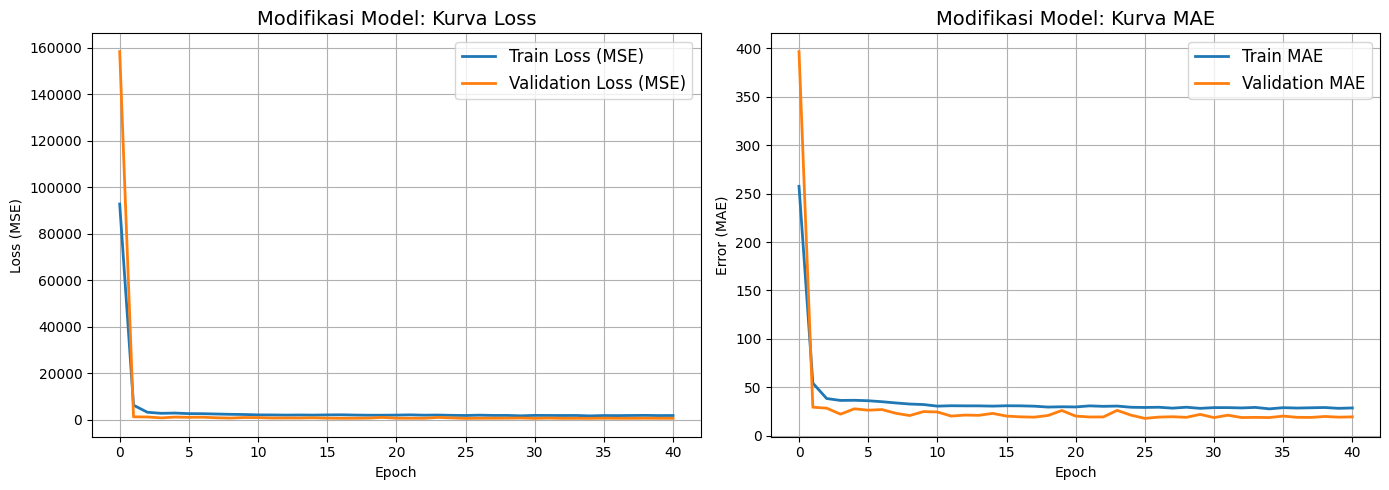

In [65]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mod.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history_mod.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.title('Modifikasi Model: Kurva Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(fontsize=12)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_mod.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history_mod.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Modifikasi Model: Kurva MAE', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Error (MAE)')
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

Perbandingan Prediksi vs Asli

In [66]:
df_googl = pd.DataFrame({
    'Harga Asli GOOGL': y_test.flatten()[:5],
    'Tebakan Model GOOGL': y_pred_mod.flatten()[:5] 
})

print("DATA PREDIKSI VS ASLI (GOOGL)")
print(df_googl)

DATA PREDIKSI VS ASLI (GOOGL)
   Harga Asli GOOGL  Tebakan Model GOOGL
0       1208.280029          1221.018799
1       1202.689941          1208.207275
2       1206.449951          1203.655884
3       1209.589966          1200.667969
4       1222.729980          1203.600464


INTC intel Corporation

In [67]:
df_INTC = pd.read_csv(DatasetPathINTC, 
                 parse_dates=["Date"], 
                 index_col=["Date"])
df_INTC.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-03-17,0.325521,0.330729,0.325521,0.325521,0.204750,10924800
1980-03-18,0.325521,0.328125,0.322917,0.322917,0.203112,17068800
1980-03-19,0.330729,0.335938,0.330729,0.330729,0.208026,18508800
1980-03-20,0.330729,0.334635,0.329427,0.329427,0.207207,11174400
1980-03-21,0.322917,0.322917,0.317708,0.317708,0.199836,12172800


In [68]:
df_INTC = pd.DataFrame(df_INTC["Close"]).rename(columns={"Close": "Price"})
df_INTC

,Price
Date,
1980-03-17,0.325521
1980-03-18,0.322917
1980-03-19,0.330729
1980-03-20,0.329427
1980-03-21,0.317708
...,...
2020-03-26,55.540001
2020-03-27,52.369999
2020-03-30,55.490002


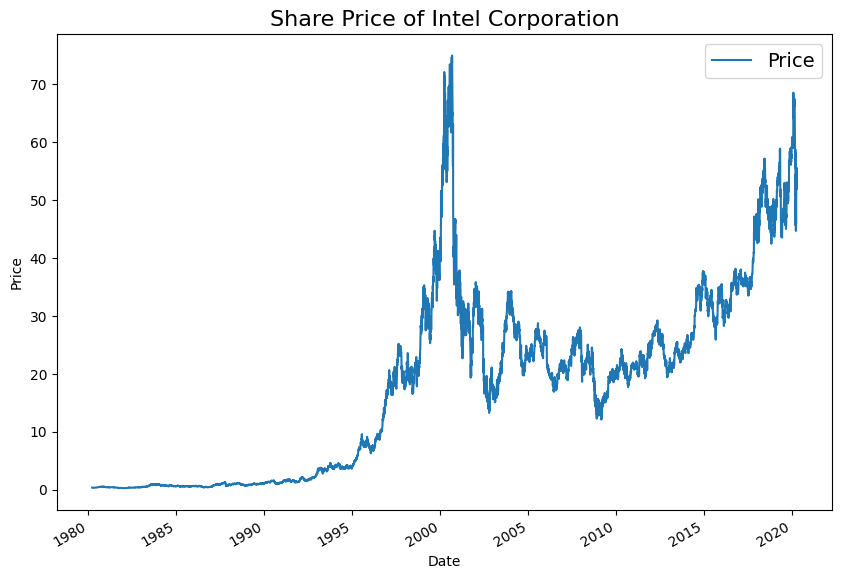

In [69]:
import matplotlib.pyplot as plt
df_INTC.plot(figsize=(10, 7))
plt.ylabel("Price")
plt.title("Share Price of Intel Corporation", fontsize=16)
plt.legend(fontsize=14);

In [70]:
df_INTC.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10098 entries, 1980-03-17 to 2020-04-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   10098 non-null  float64
dtypes: float64(1)
memory usage: 157.8 KB


In [71]:
tanggal_terakhir = df_INTC.index.max()

batas_satu_tahun = tanggal_terakhir - pd.DateOffset(years=1)

print(f"Tanggal paling akhir di data: {tanggal_terakhir.date()}")
print(f"Batas potong 1 tahun terakhir: {batas_satu_tahun.date()}\n")

data_train_full = df_INTC[df_INTC.index < batas_satu_tahun]['Price'].values

data_test = df_INTC[df_INTC.index >= batas_satu_tahun]['Price'].values

print(f"Total data train awal: {len(data_train_full)} hari")
print(f"Total data test: {len(data_test)} hari")

Tanggal paling akhir di data: 2020-04-01
Batas potong 1 tahun terakhir: 2019-04-01

Total data train awal: 9844 hari
Total data test: 254 hari


In [72]:
window_size = 5
horizon = 1

x_train_windowed, y_train_windowed = create_windows(data_train_full, window_size, horizon)
x_test, y_test = create_windows(data_test, window_size, horizon)

In [73]:
split_size = int(0.9 * len(x_train_windowed))

x_train = x_train_windowed[:split_size]
y_train = y_train_windowed[:split_size]

x_val = x_train_windowed[split_size:]
y_val = y_train_windowed[split_size:]

print(f"x_train shape : {x_train.shape}, y_train shape : {y_train.shape}")
print(f"x_val shape   : {x_val.shape}, y_val shape   : {y_val.shape}")
print(f"x_test shape  : {x_test.shape}, y_test shape  : {y_test.shape}")

x_train shape : (8855, 5), y_train shape : (8855, 1)
x_val shape   : (984, 5), y_val shape   : (984, 1)
x_test shape  : (249, 5), y_test shape  : (249, 1)


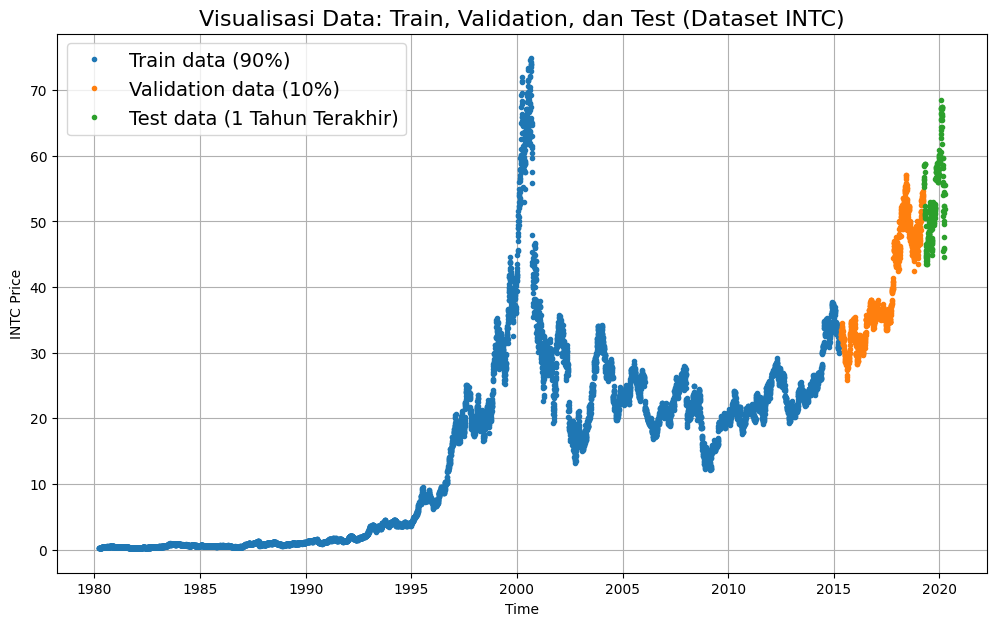

In [74]:
offset = window_size + horizon - 1

tabel_train_baru = df_INTC[df_INTC.index < batas_satu_tahun]
tabel_test_baru = df_INTC[df_INTC.index >= batas_satu_tahun]

timesteps_train_full_baru = tabel_train_baru.index
timesteps_test_full_baru = tabel_test_baru.index

timesteps_y_train_full = timesteps_train_full_baru[offset:]
timesteps_y_test = timesteps_test_full_baru[offset:]

timesteps_train = timesteps_y_train_full[:split_size]
timesteps_val = timesteps_y_train_full[split_size:]

plt.figure(figsize=(12, 7))

plt.plot(timesteps_train, y_train.flatten(), ".", label="Train data (90%)")
plt.plot(timesteps_val, y_val.flatten(), ".", label="Validation data (10%)")
plt.plot(timesteps_y_test, y_test.flatten(), ".", label="Test data (1 Tahun Terakhir)")

plt.xlabel("Time")
plt.ylabel("INTC Price")
plt.title("Visualisasi Data: Train, Validation, dan Test (Dataset INTC)", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.show()

Model Baseline INTC

In [75]:
x_train_3d_v2 = np.expand_dims(x_train, axis=-1)
x_val_3d_v2 = np.expand_dims(x_val, axis=-1)
x_test_3d_v2 = np.expand_dims(x_test, axis=-1)

print(f"x_train_3d_v2 shape : {x_train_3d_v2.shape}")
print(f"x_val_3d_v2 shape   : {x_val_3d_v2.shape}")
print(f"x_test_3d_v2 shape  : {x_test_3d_v2.shape}\n")


model_baseline_v2 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(units=50, activation='relu', input_shape=(window_size, 1)),
    
    tf.keras.layers.Dense(units=1)
])


model_baseline_v2.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_baseline_v2.summary()

x_train_3d_v2 shape : (8855, 5, 1)
x_val_3d_v2 shape   : (984, 5, 1)
x_test_3d_v2 shape  : (249, 5, 1)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
history_baseline_v2 = model_baseline_v2.fit(
    x_train_3d_v2, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_val_3d_v2, y_val),
    verbose=1
)

Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 33.1667 - mae: 1.9089 - val_loss: 1.1576 - val_mae: 0.8224
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6009 - mae: 0.4072 - val_loss: 0.7079 - val_mae: 0.6314
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4899 - mae: 0.3707 - val_loss: 0.7552 - val_mae: 0.6735
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4459 - mae: 0.3511 - val_loss: 0.7271 - val_mae: 0.6604
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4243 - mae: 0.3404 - val_loss: 0.7119 - val_mae: 0.6548
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4118 - mae: 0.3343 - val_loss: 0.6753 - val_mae: 0.6345
Epoch 7/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4034 - mae: 0.3302 - val_loss: 0.6376 - val_mae: 0.6107
Epoch 8/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3969 - mae: 0.3266 - val_loss: 0.6081 - val_mae: 0.5901
Epoch 9/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - l

In [77]:
y_pred_baseline_v2 = model_baseline_v2.predict(x_test_3d_v2)

rmse_baseline_v2 = np.sqrt(mean_squared_error(y_test, y_pred_baseline_v2))

mae_baseline_v2 = mean_absolute_error(y_test, y_pred_baseline_v2)

mape_baseline_v2 = mean_absolute_percentage_error(y_test, y_pred_baseline_v2)

print("\nEVALUASI MODEL BASELINE")
print(f"Nilai RMSE : {rmse_baseline_v2:.4f}")
print(f"Nilai MAE  : {mae_baseline_v2:.4f}")
print(f"Nilai MAPE : {mape_baseline_v2:.4f} (atau setara dengan {mape_baseline_v2 * 100:.2f}%)")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step

EVALUASI MODEL BASELINE
Nilai RMSE : 1.5970
Nilai MAE  : 1.0080
Nilai MAPE : 0.0190 (atau setara dengan 1.90%)


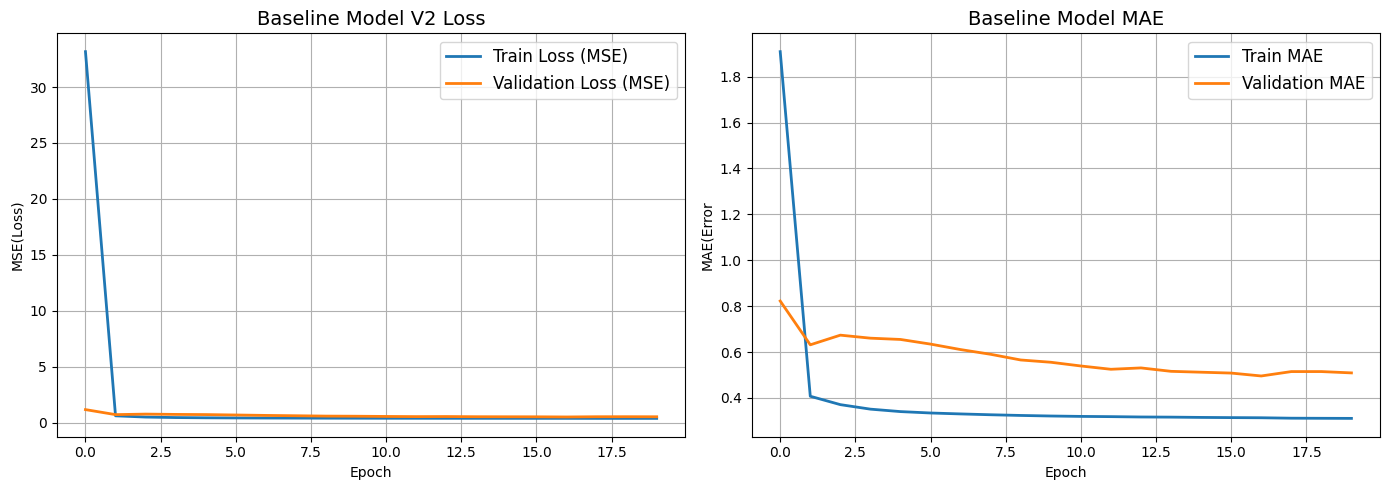

In [78]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_baseline_v2.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history_baseline_v2.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.title('Baseline Model V2 Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MSE(Loss)')
plt.legend(fontsize=12)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_baseline_v2.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history_baseline_v2.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Baseline Model MAE', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('MAE(Error')
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

Model Modifikasi INTC

In [79]:
model_mod_v2 = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(
        units=50, 
        activation='relu', 
        input_shape=(window_size, 1)
    ),
    
    tf.keras.layers.Dropout(0.1),

    tf.keras.layers.Dense(units=1)
])

model_mod_v2.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
model_mod_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop_v2 = EarlyStopping(
    monitor='val_loss',       
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor='val_loss',       
    factor=0.5,
    patience=5,               
    min_lr=1e-6,              
    verbose=1
)

In [81]:
history_mod_v2 = model_mod_v2.fit(
    x_train_3d_v2, y_train,   
    epochs=150,               
    batch_size=64,
    validation_data=(x_val_3d_v2, y_val),
    callbacks=[early_stop_v2, reduce_lr_v2], 
    verbose=1
)

Epoch 1/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 113.5112 - mae: 5.4614 - val_loss: 1.6220 - val_mae: 0.9315 - learning_rate: 5.0000e-04
Epoch 2/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2885 - mae: 1.4060 - val_loss: 1.1511 - val_mae: 0.7833 - learning_rate: 5.0000e-04
Epoch 3/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.7890 - mae: 1.1939 - val_loss: 1.2565 - val_mae: 0.8348 - learning_rate: 5.0000e-04
Epoch 4/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.7925 - mae: 1.0934 - val_loss: 1.3429 - val_mae: 0.9498 - learning_rate: 5.0000e-04
Epoch 5/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4269 - mae: 1.0289 - val_loss: 2.1996 - val_mae: 1.2989 - learning_rate: 5.0000e-04
Epoch 6/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.3552 - mae: 1.0319 - val_loss: 1.1831 - val_mae: 0.8448 - learning_rate: 5.0000e-04
Epoch 7/150
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.3179 - mae: 1.0289 - val_loss: 0.5744 - val_mae: 0.5

In [82]:
y_pred_mod_v2 = model_mod_v2.predict(x_test_3d_v2)

rmse_mod_v2 = np.sqrt(mean_squared_error(y_test, y_pred_mod_v2))

mae_mod_v2 = mean_absolute_error(y_test, y_pred_mod_v2)

mape_mod_v2 = mean_absolute_percentage_error(y_test, y_pred_mod_v2)

print("\n HASIL EVALUASI MODEL MODIFIKASI V2")
print(f"Nilai RMSE : {rmse_mod_v2:.4f}")
print(f"Nilai MAE  : {mae_mod_v2:.4f}")
print(f"Nilai MAPE : {mape_mod_v2:.4f} (atau setara dengan {mape_mod_v2 * 100:.2f}%)")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step

 HASIL EVALUASI MODEL MODIFIKASI V2
Nilai RMSE : 1.5269
Nilai MAE  : 0.9597
Nilai MAPE : 0.0181 (atau setara dengan 1.81%)


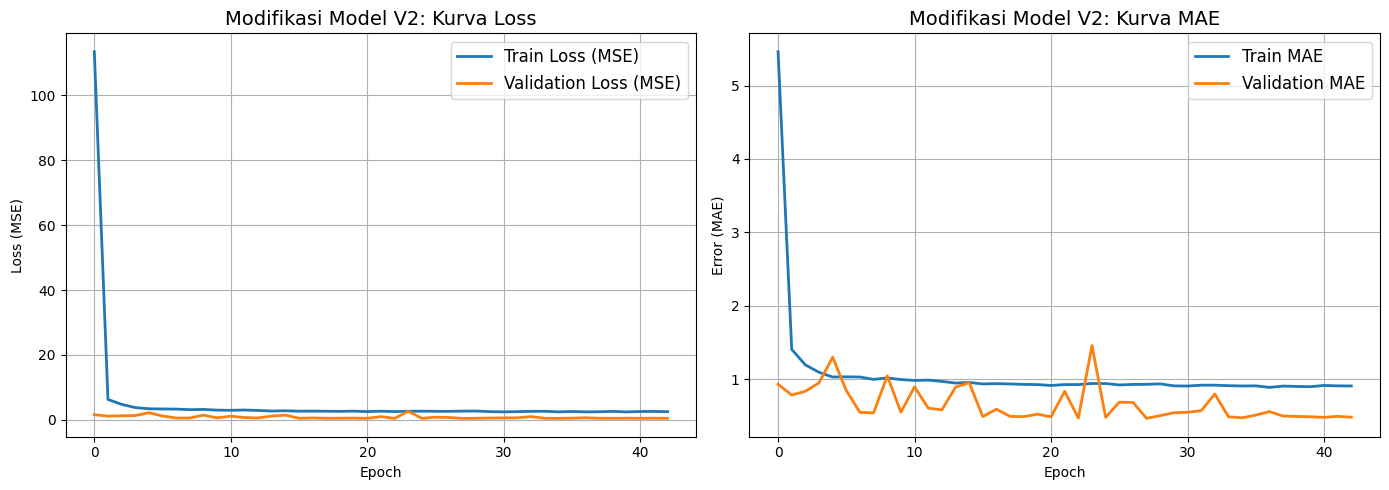

In [83]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_mod_v2.history['loss'], label='Train Loss (MSE)', linewidth=2)
plt.plot(history_mod_v2.history['val_loss'], label='Validation Loss (MSE)', linewidth=2)
plt.title('Modifikasi Model V2: Kurva Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(fontsize=12)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_mod_v2.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history_mod_v2.history['val_mae'], label='Validation MAE', linewidth=2)
plt.title('Modifikasi Model V2: Kurva MAE', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Error (MAE)')
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

Perbandingan Prediksi vs Asli

In [84]:
df_intc = pd.DataFrame({
    'Harga Asli INTC': y_test.flatten()[:5],
    'Tebakan Model INTC': y_pred_mod_v2.flatten()[:5]
})

print("DATA PREDIKSI VS ASLI (INTC)")
print(df_intc)

DATA PREDIKSI VS ASLI (INTC)
   Harga Asli INTC  Tebakan Model INTC
0        55.680000           55.384815
1        55.320000           55.479683
2        55.750000           55.157372
3        55.799999           55.481815
4        56.419998           55.555447


## Kesimpulan

### Apakah ini bagus ?
##### Jika untuk real case ini buruk -> biasanya margin seorang trader hanya di range 0.5% - 1%, jika diatas 1% maka bisa dikatakan model berbahaya untuk digunakan karena bisa menimbulkan kerugian

#

## Apakah ini layak untuk dideploy ?
##### Jawabanya tidak, karena di dunia trading, memerlukan model yang sangat presisi untuk ememnuhi profit harian

## Bagaimana Cara Improvisasi/Saran Untuk Memperbaiki Model ?
##### 1. Model memerlukan fitur yang jauh lebih luas(Multivariate)
##### 2. Model memerlukan distribusi data yang tidak ekstrem
##### 3. Scaling pada data